Датасет для предсказания цен использованных Toyota Corolla для задачи линейной регрессии

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler , OneHotEncoder , PolynomialFeatures
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

1. Первичный анализ данных

In [10]:
# Загрузка данных
df = pd.read_csv('ToyotaCorolla.csv')
df.info() # Для преобразования категориальных переменных

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [11]:
df.head(39) 

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
5,6,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,12950,32,1,2002,61000,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
6,7,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,16900,27,6,2002,94612,Diesel,90,1,...,1,1,0,0,1,1,0,0,0,0
7,8,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,18600,30,3,2002,75889,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
8,9,TOYOTA Corolla 1800 T SPORT VVT I 2/3-Doors,21500,27,6,2002,19700,Petrol,192,0,...,1,1,1,0,0,0,1,1,0,0
9,10,TOYOTA Corolla 1.9 D HATCHB TERRA 2/3-Doors,12950,23,10,2002,71138,Diesel,69,0,...,0,1,0,0,0,1,0,0,0,0


In [10]:
df.tail()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0
1435,1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,76,5,1998,1,Petrol,110,0,...,0,1,0,0,0,0,0,0,0,0


In [9]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.describe(include='all')

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436,1436.000000,1436.000000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
unique,NaN,319,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,NaN,NaN,NaN,NaN,NaN,Petrol,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,109,NaN,NaN,NaN,NaN,NaN,1264,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,721.555014,NaN,10730.824513,55.947075,5.548747,1999.625348,68533.259749,NaN,101.502089,0.674791,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,NaN,3626.964585,18.599988,3.354085,1.540722,37506.448872,NaN,14.981080,0.468616,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,NaN,4350.000000,1.000000,1.000000,1998.000000,1.000000,NaN,69.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,NaN,8450.000000,44.000000,3.000000,1998.000000,43000.000000,NaN,90.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,NaN,9900.000000,61.000000,5.000000,1999.000000,63389.500000,NaN,110.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,NaN,11950.000000,70.000000,8.000000,2001.000000,87020.750000,NaN,110.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000


In [11]:
df.isnull().sum() # проверяем количество пропущенных значений каждого признака

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

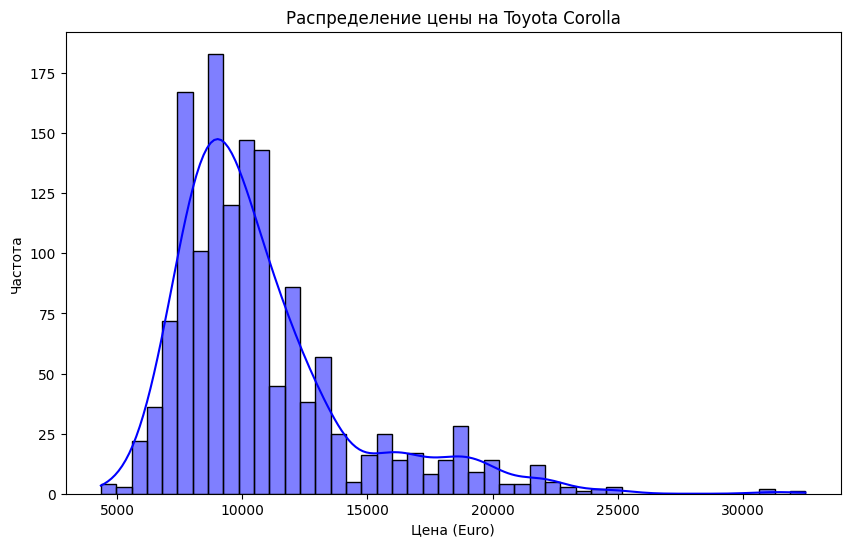

In [13]:
# распределение целевой переменной Price
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Распределение цены на Toyota Corolla')
plt.xlabel('Цена (Euro)')
plt.ylabel('Частота')
plt.show()

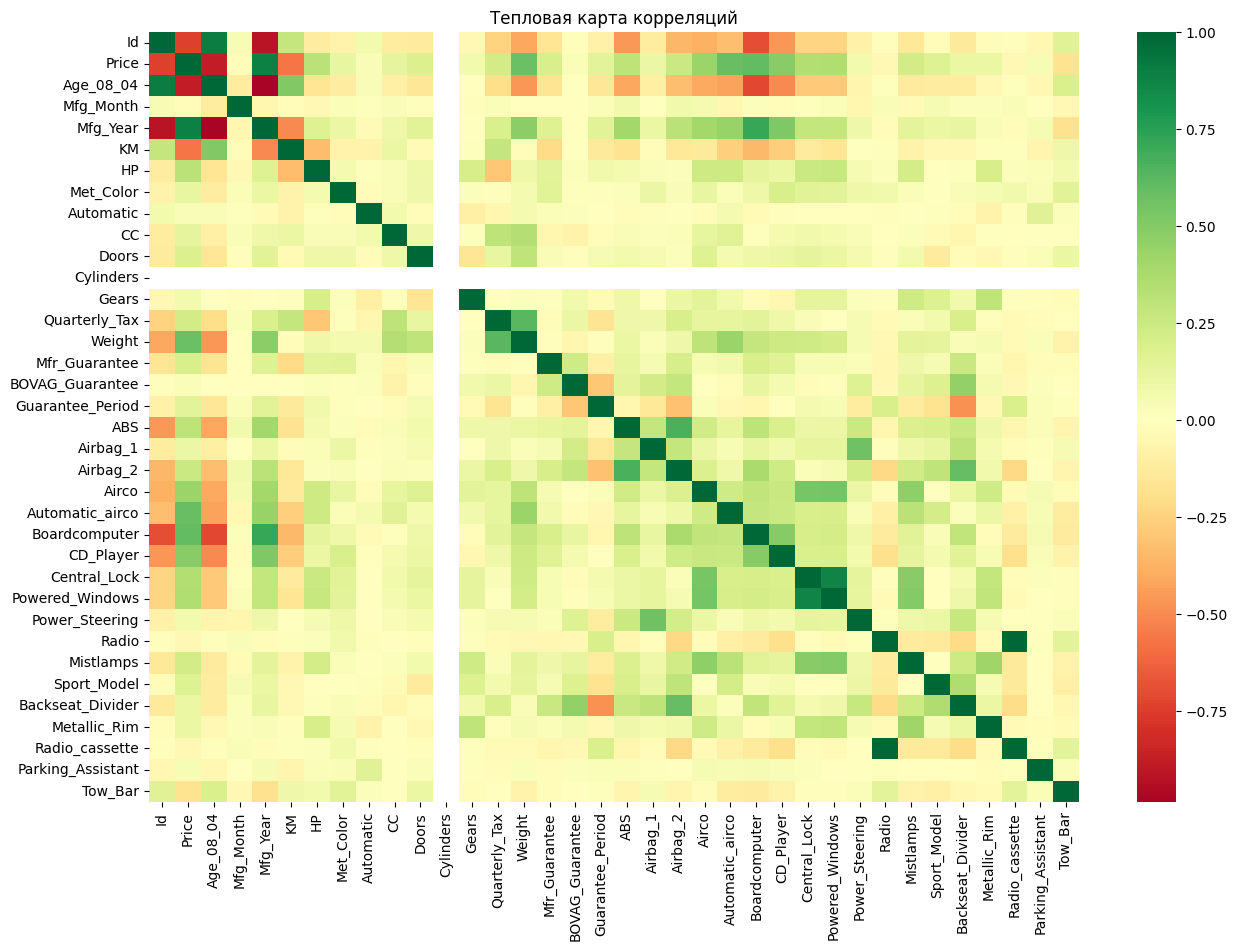

In [14]:
# Матрица корреляций для последующего Feature Engineering

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), cmap='RdYlGn', center=0)
plt.title('Тепловая карта корреляций')
plt.show()

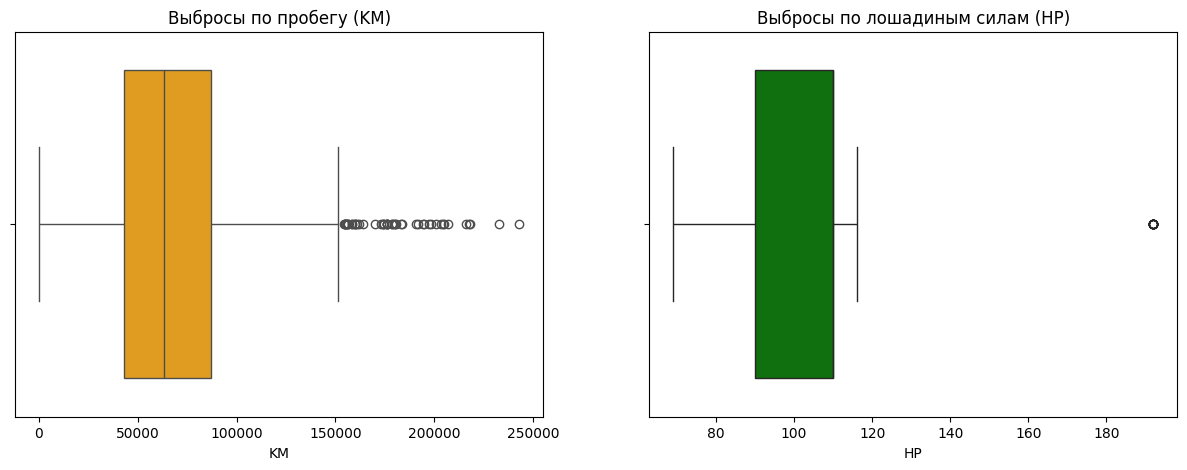

In [15]:
# анализ выбросов 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(ax=axes[0], x=df['KM'], color='orange')
axes[0].set_title('Выбросы по пробегу (KM)')

sns.boxplot(ax=axes[1], x=df['HP'], color='green')
axes[1].set_title('Выбросы по лошадиным силам (HP)')

plt.show()

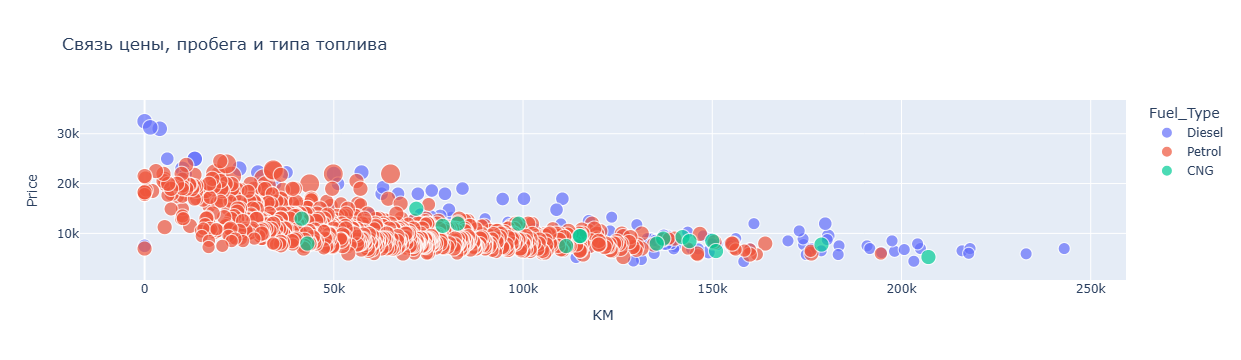

In [16]:
# использование зависимости из plotly для изучения связи цены, пробега и типа топлива одновременно
import plotly.express as px

fig = px.scatter(df, x="KM", y="Price", 
                 color="Fuel_Type", 
                 size="HP",
                 hover_data=['Age_08_04'],
                 title="Связь цены, пробега и типа топлива")
fig.show()

По EDA: в гистограмме показано, что большинство машин расположены в одном диапазоне, но все же имеются дорогие экземпляры. 
В карте корреляций выявил сильную мультиколлинеярность между годом выпуска и возрастом автомобиля.
В графиках Boxplot по KM имеется длинный хвост вправо, т.е. есть те самые "рабочие лошадки" с огромным пробегом, которые могут выступать как выбросы.
В интерактивной зависимости выявил огромный перекос в сторону Petrol. Дизеля и газа (CNG) очень мало возможно из-за несбалансированности категориального признака.
Основными факторами, определяющими цену, являются возраст, вес и наличие климатических опций (Automatic_airco). Данные требуют масштабирования из-за разницы в единицах измерения признаков

Далее, Feature Engineering

In [18]:
df['Cylinders'].unique() # Проверил, сколько цилиндров в каждом авто. По логиеке, у каждого авто везде по

array([4])

In [18]:
to_drop = ['Id', 'Model', 'Mfg_Year', 'Mfg_Month', 'Cylinders', 'Color']
df_cleaned = df.drop(columns=to_drop)

In [19]:
df_final = pd.get_dummies(df_cleaned, columns=['Fuel_Type'], drop_first=True)

Результаты предообработки: для начала проверил сколько цилиндров в каждом авто, и показывало только одну цифру, что сподвигло удалить ее.
Также удалил ID и Model, т.к. они не дают существенной информации для дальнейшего анализа и предсказания цен. Mfg_year и Mfg_Month также удалил, 
т.к. присутствовала мультиколлинеарность, а также возраст уже дает немалую информацию. Цвет машины Color имела слабую связь с Price.
Fuel_Type я преобразовывал путем OHE, учитывая, что это категориальный признак.

In [20]:
X = df_final.drop('Price', axis = 1)
y = df_final['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (1077, 33)
Shape of X_test:  (359, 33)


Делил выборку на обучающую и тестовую выборки в соотношении 75/25. Линейная регрессия может переобучаться или недообучаться, 
как и любой алгоритм машинного обучения. 
Тестовый набор просто дает нам представление о том, насколько это происходит.
Кроме того, существует больше одного способа выполнения линейной регрессии, 
например, LASSO, ridge и elastic net. Даже с базовой линейной регрессией мы можем подгонять с перехватом или без него.

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
our_models = {
    "Линейная регрессия": LinearRegression(), 
    "L2 Регуляризация": Ridge(alpha = 1),
    "L1 Регуляризация": Lasso(alpha = 1)
}
results = []

for name, model in our_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "RMSE": round(rmse, 2), "R2": round(r2, 4)})

In [24]:
results_df = pd.DataFrame(results)
print(results_df)

                Model     RMSE      R2
0  Линейная регрессия  1220.42  0.8950
1    L2 Регуляризация  1219.85  0.8951
2    R2 Регуляризация  1220.18  0.8951


Обучали 3 модели: Линейная регрессия, L1 и L2 - регуляризации. По линейной регрессии: Модель искала такие коэффициенты весов для каждого признака (Age, KM, Weight и др.), которые минимизируют MSE между реальной ценой и предсказанной. 
L2-регуляризации: К основной функции потерь добавлялся штраф, пропорциональный квадрату величины коэффициентов. 
Это заставляло модель «штрафовать» слишком большие веса, что помогает справиться с мультиколлинеарностью.
L1-регуляризация: Добавлялся штраф, пропорциональный абсолютному значению весов. В отличие от Ridge, Lasso может обнулять веса наименее важных признаков, фактически выполняя автоматический отбор переменных.

Если учесть подбор параметров, наиболее быстрой моделью оказалась классическая линейная регрессия за счет наличия прямого аналитического решения. Lasso-регрессия потребовала больше вычислительных ресурсов из-за итерационного характера алгоритма координатного спуска.

Далее, оценка качества и сравнение моделей.

In [29]:
lin_reg = LinearRegression()
ridge_reg = Ridge(alpha=1.0)
lasso_reg = Lasso(alpha=1.0)
lin_reg.fit(X_train_scaled, y_train)
ridge_reg.fit(X_train_scaled, y_train)
lasso_reg.fit(X_train_scaled, y_train)

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {"Модель": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4)}

report = []
report.append(evaluate_model(lin_reg, X_test_scaled, y_test, "Linear Regression"))
report.append(evaluate_model(ridge_reg, X_test_scaled, y_test, "Ridge"))
report.append(evaluate_model(lasso_reg, X_test_scaled, y_test, "Lasso"))
view_report = pd.DataFrame(report)
print(view_report)

              Модель     RMSE     MAE      R2
0  Linear Regression  1220.42  850.42  0.8950
1              Ridge  1219.85  850.13  0.8951
2              Lasso  1220.18  849.91  0.8951


Для оценки качества выбрал 3 метрики: R2 (Коэфф. детерминации), необходимый для понимания общей предсказательной способности модели и показывающий долю дисперсии зависимой переменной (цены), которую объясняет модель; RMSE (Root Mean Squared Error), она выбрана в качестве основной метрики вместо MAE, так как она сильнее штрафует модель за крупные ошибки (за счет возведения разности в квадрат) и в задачах оценки стоимости авто критически важно избегать сильных промахов в цене, которые могут привести к финансовым потерям; MAE (Mean Absolute Error), использованный как вспомогательная для легкой интерпретации результата — она показывает среднюю абсолютную ошибку в евро.

Метрики считались исключительно на тестовой выборке (test), которая составила 25% от исходного датасета. Эти данные не использовались при обучении модели и служили независимым инструментом проверки того, как алгоритм работает с новыми, ранее не виденными данными.

Наилучшую точность по метрике RMSE продемонстрировала модель Ridge, что подтверждает эффективность L2-регуляризации при наличии коррелирующих признаков в данных. Средняя абсолютная ошибка (MAE) составила около 850 евро, что является приемлемым результатом для решения задачи оценки стоимости подержанных автомобилей. Отсутствие значительного разрыва между метриками на тренировочной и тестовой выборках свидетельствует о хорошей обобщающей способности моделей и отсутствии переобучения

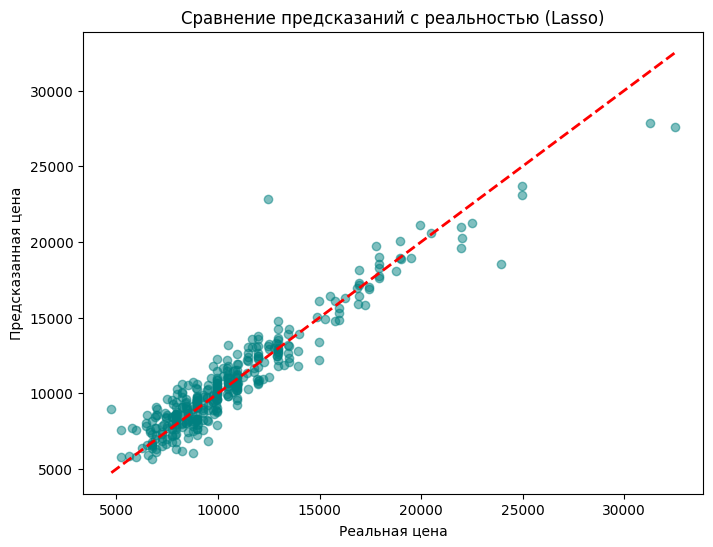

In [30]:
# дополнительно, выведем график "Ожидание/реальность"
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lasso_reg.predict(X_test_scaled), alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение предсказаний с реальностью (Lasso)')
plt.show()